In [2]:
# Install required details
!pip install pandas scikit-learn

In [32]:
# import modules
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import time
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [4]:
# load data using pandas
df=pd.read_csv('https://raw.githubusercontent.com/redashu/Intuit_ML_13thMay2026/refs/heads/master/datasets/data_preprocess1.csv')


In [5]:
# dataset info
print("\n ====Dataset info === \n")
print(df.info())


 ====Dataset info === 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    30 non-null     object 
 1   Age        29 non-null     float64
 2   Salary     28 non-null     float64
 3   Purchased  30 non-null     object 
dtypes: float64(2), object(2)
memory usage: 1.1+ KB
None


In [6]:
# choosing features / input  & label / output
features = df.iloc[:,0:3].values
label = df.iloc[:,-1].values
print(features)
time.sleep(2)
print("_______________")
print(label)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 nan]
 ['France' 35.0 58000.0]
 ['Spain' nan 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]
 ['Germany' 28.0 49000.0]
 ['France' 42.0 75000.0]
 ['Spain' 33.0 56000.0]
 ['Germany' 45.0 77000.0]
 ['France' 29.0 51000.0]
 ['Spain' 51.0 85000.0]
 ['Germany' 36.0 nan]
 ['France' 31.0 55000.0]
 ['Spain' 39.0 63000.0]
 ['Germany' 47.0 80000.0]
 ['France' 26.0 47000.0]
 ['Spain' 32.0 53000.0]
 ['Germany' 41.0 71000.0]
 ['France' 49.0 82000.0]
 ['Spain' 34.0 57000.0]
 ['Germany' 43.0 74000.0]
 ['France' 52.0 88000.0]
 ['Spain' 46.0 78000.0]
 ['Germany' 25.0 45000.0]
 ['France' 53.0 90000.0]]
_______________
['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes'
 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'No' 'Yes' 'No'
 'Yes' 'No' 'Yes' 'No']


In [7]:
# handle the missing values part
# handling missing values using sklearn for numerical cols
num_imputer = SimpleImputer(strategy='mean')

# take only those columns from feature where imputation required
num_imputer.fit(features[:,1:3])
features[:,1:3]=num_imputer.transform(features[:,1:3])
print(features)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 66071.42857142857]
 ['France' 35.0 58000.0]
 ['Spain' 39.0 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]
 ['Germany' 28.0 49000.0]
 ['France' 42.0 75000.0]
 ['Spain' 33.0 56000.0]
 ['Germany' 45.0 77000.0]
 ['France' 29.0 51000.0]
 ['Spain' 51.0 85000.0]
 ['Germany' 36.0 66071.42857142857]
 ['France' 31.0 55000.0]
 ['Spain' 39.0 63000.0]
 ['Germany' 47.0 80000.0]
 ['France' 26.0 47000.0]
 ['Spain' 32.0 53000.0]
 ['Germany' 41.0 71000.0]
 ['France' 49.0 82000.0]
 ['Spain' 34.0 57000.0]
 ['Germany' 43.0 74000.0]
 ['France' 52.0 88000.0]
 ['Spain' 46.0 78000.0]
 ['Germany' 25.0 45000.0]
 ['France' 53.0 90000.0]]


In [8]:
# label encoding -- conversion 2 category cols values into number
label_encoder = LabelEncoder()
label = label_encoder.fit_transform(label)
print(label)

[0 1 0 0 1 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1 0]


In [9]:
# dealing with multi category values cols
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[0])],remainder='passthrough')
features = ct.fit_transform(features)
print(features)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 66071.42857142857]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 39.0 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]
 [0.0 1.0 0.0 28.0 49000.0]
 [1.0 0.0 0.0 42.0 75000.0]
 [0.0 0.0 1.0 33.0 56000.0]
 [0.0 1.0 0.0 45.0 77000.0]
 [1.0 0.0 0.0 29.0 51000.0]
 [0.0 0.0 1.0 51.0 85000.0]
 [0.0 1.0 0.0 36.0 66071.42857142857]
 [1.0 0.0 0.0 31.0 55000.0]
 [0.0 0.0 1.0 39.0 63000.0]
 [0.0 1.0 0.0 47.0 80000.0]
 [1.0 0.0 0.0 26.0 47000.0]
 [0.0 0.0 1.0 32.0 53000.0]
 [0.0 1.0 0.0 41.0 71000.0]
 [1.0 0.0 0.0 49.0 82000.0]
 [0.0 0.0 1.0 34.0 57000.0]
 [0.0 1.0 0.0 43.0 74000.0]
 [1.0 0.0 0.0 52.0 88000.0]
 [0.0 0.0 1.0 46.0 78000.0]
 [0.0 1.0 0.0 25.0 45000.0]
 [1.0 0.0 0.0 53.0 90000.0]]


In [10]:
# spliting data into training testing part
(train_ft,test_ft,train_label,test_label)=train_test_split(features,label,test_size=0.1)
# testsize 0 to 1 -- 0.1 means 10% testing data

In [11]:
print(train_ft.shape)
print(test_ft.shape)


(27, 5)
(3, 5)


In [15]:
# exploring Decisiontree
#help(DecisionTreeClassifier())
classifier = DecisionTreeClassifier()

In [16]:
# Train DecisionTree classifier
trained_model = classifier.fit(train_ft,train_label)

In [17]:
# using test_features to predict label
predicted_values = trained_model.predict(test_ft)


In [18]:
# printing actual values
print(test_label)

[1 0 0]


In [21]:
print(predicted_values)

[1 0 0]


In [23]:
# using accuracy score to see the accuracy of classifier
desc_score = accuracy_score(test_label,predicted_values)
print(desc_score) # output is 0 to 1

1.0


In [30]:
# lets try user input
ashu_new_data = np.array([['Spain','39','510000']])

# transform newdata input
ashu_tf_data = ct.transform(ashu_new_data)
print(ashu_tf_data)


[['0.0' '0.0' '1.0' '39' '510000']]


In [33]:
trained_model.predict(ashu_tf_data)
#

array([1])

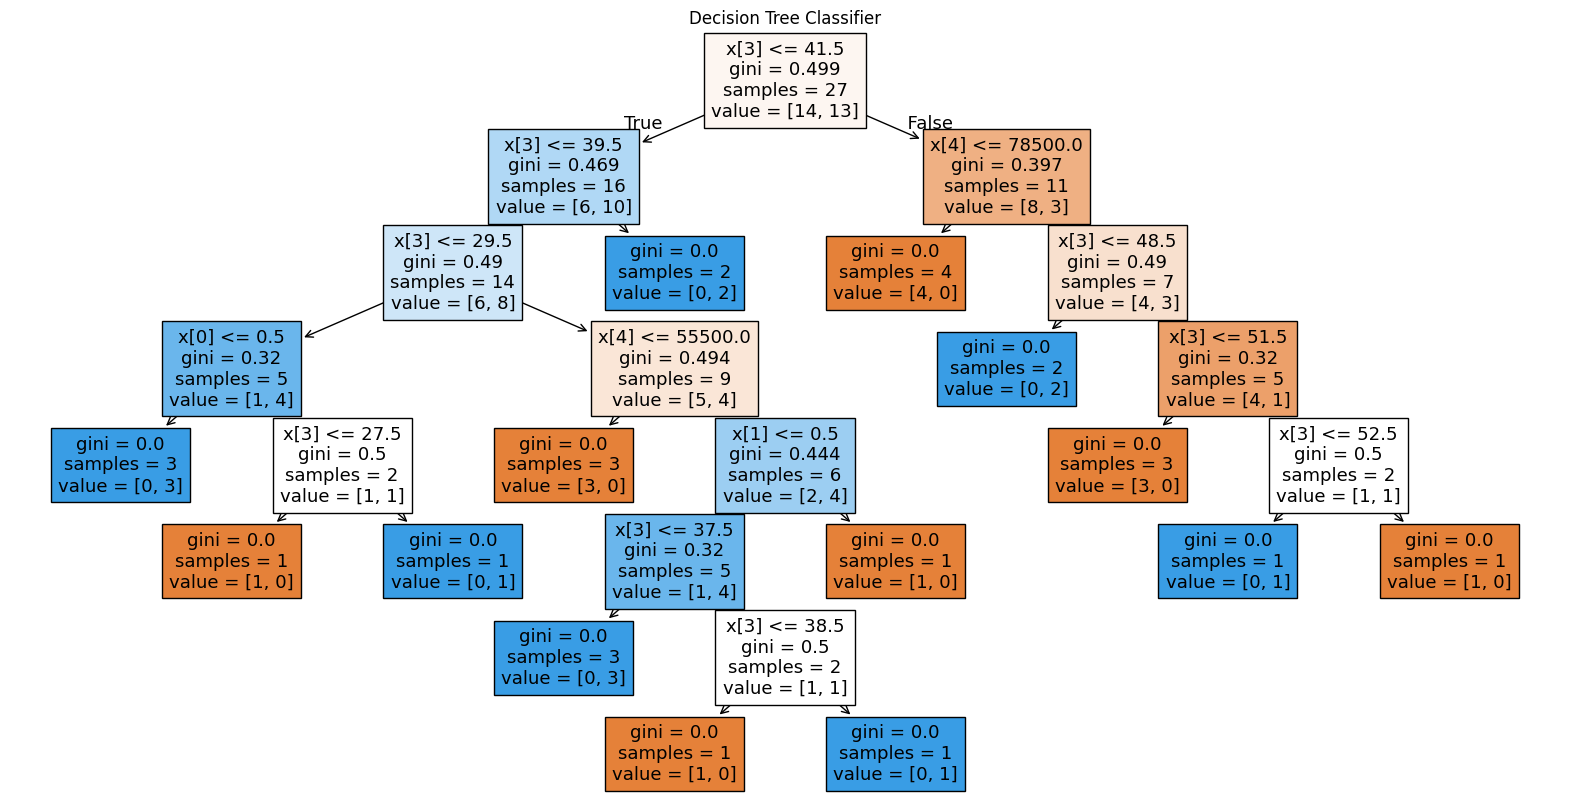

In [40]:
# lets visulize tree
plt.figure(figsize=(20,10))
plot_tree(trained_model,filled=True)
# #plot_tree(classifier,
#           feature_names=ct.get_feature_names_out(),
#           class_names=label_encoder.classes_,
#           filled=True)
plt.title("Decision Tree Classifier")
plt.show()